In [ ]:
# --- project bootstrap ---
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
os.chdir(ROOT)
# -------------------------


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import fgtn.classA_U1FGTN as classA_U1FGTN
importlib.reload(classA_U1FGTN)
from fgtn.classA_U1FGTN import classA_U1FGTN
# Lattice + mass profile
Nx, Ny = 16, 16
alpha_top  = 1  # topological slab mass
alpha_triv = 30 # trivial slab mass

def ensure_wannier(model):
    if not all(hasattr(model, a) for a in ("WF_Ap", "WF_Bp", "WF_Am", "WF_Bm")):
        model.construct_OW_projectors(nshell=model.nshell, DW=model.DW)

def neg_semidefinite_H_from_Wannier(model):
    """H = -(sum lower occ projectors + sum upper (1-occ) projectors)."""
    ensure_wannier(model)
    Nx, Ny = model.Nx, model.Ny
    dim = 2 * Nx * Ny
    Hsum = np.zeros((dim, dim), dtype=np.complex128)
    for Rx in range(Nx):
        for Ry in range(Ny):
            P_Am = model._proj_from_WF(model.WF_Am, Rx, Ry)  # lower A
            P_Bm = model._proj_from_WF(model.WF_Bm, Rx, Ry)  # lower B
            P_Ap = model._proj_from_WF(model.WF_Ap, Rx, Ry)  # upper A
            P_Bp = model._proj_from_WF(model.WF_Bp, Rx, Ry)  # upper B
            Hsum += P_Am + P_Bm
            Hsum += (np.eye(dim) - P_Ap) + (np.eye(dim) - P_Bp)
    Hsum /= (2 * Nx * Ny)
    # enforce Hermiticity and flip sign => negative semidefinite
    return -0.5 * (Hsum + Hsum.conj().T)

def spectrum(H):
    evals = np.linalg.eigvalsh(H)
    return np.sort(np.real_if_close(evals))


In [14]:

# No domain wall: uniform alpha=1 (topological)
m_no_dw = classA_U1FGTN(Nx=Nx, Ny=Ny, DW=False, nshell = 2, alpha_top=alpha_top, alpha_triv=alpha_triv)
H_no_dw = neg_semidefinite_H_from_Wannier(m_no_dw)
evals_no_dw = spectrum(H_no_dw)

# With domain wall: trivial mass=30 outside, top mass=1 in the slab
m_dw = classA_U1FGTN(Nx=Nx, Ny=Ny, DW=True, nshell = 2, alpha_top=alpha_top, alpha_triv=alpha_triv)
H_dw = neg_semidefinite_H_from_Wannier(m_dw)
evals_dw = spectrum(H_dw)


TypeError: classA_U1FGTN.__init__() got an unexpected keyword argument 'alpha_top'

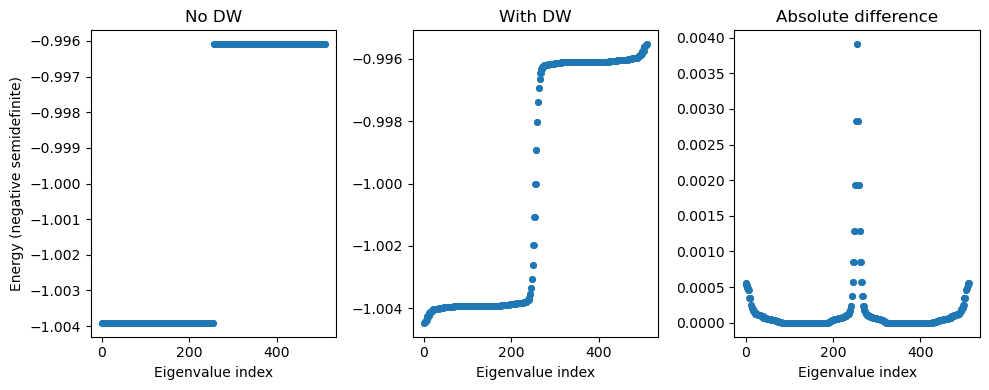

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].plot(evals_no_dw, "o", ms=4, label="No DW (alpha=1)")
axes[0].set_xlabel("Eigenvalue index")
axes[0].set_ylabel("Energy (negative semidefinite)")
axes[0].set_title("No DW")

axes[1].plot(evals_dw, "o", ms=4, label=f"DW (alpha_top={alpha_top}, alpha_triv={alpha_triv})")
axes[1].set_xlabel("Eigenvalue index")
axes[1].set_title("With DW")

axes[2].plot(np.abs(evals_dw-evals_no_dw), "o", ms=4, label=f"DW (alpha_top={alpha_top}, alpha_triv={alpha_triv})")
axes[2].set_xlabel("Eigenvalue index")
axes[2].set_title("Absolute difference")

plt.tight_layout()
plt.show()


(array([64]),)
(array([], dtype=int64),)


DWs at x=(5, 14)
------------------------- classA_U1FGTN Initialized -------------------------


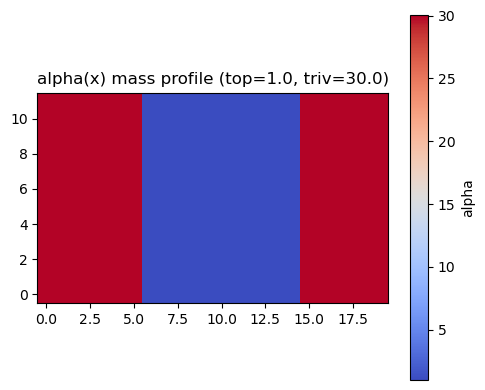

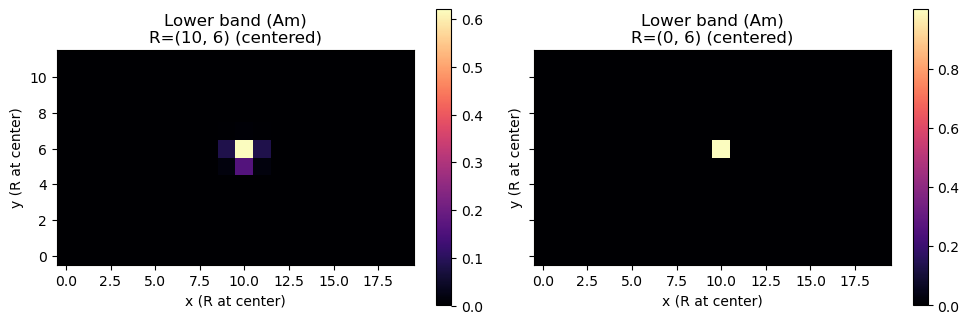

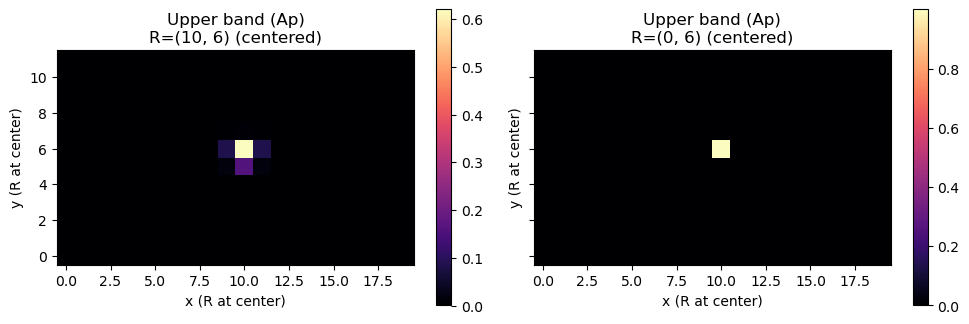

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from fgtn.classA_U1FGTN import classA_U1FGTN
# Lattice and DW profile
Nx, Ny = 20, 12
alpha_top  = 1.0
alpha_triv = 30.0
model = classA_U1FGTN(Nx=Nx, Ny=Ny, DW=True, alpha_top=alpha_top, alpha_triv=alpha_triv)
model.construct_OW_projectors(nshell=model.nshell, DW=model.DW)

# Centers to compare (pick topological vs trivial)
R_top  = (Nx // 2, Ny // 2)
R_triv = (0, Ny // 2)

def wannier_weight_at_R_centered(model, WF, R):
    """Return |chi(x,y)|^2 with R shifted to the plot center."""
    Rx, Ry = R
    chi = np.array(WF[:, Rx, Ry], copy=True)
    chi_xyz = chi.reshape(2, Nx, Ny, order='F')
    weight = np.sum(np.abs(chi_xyz)**2, axis=0)
    # shift so R lands at (Nx//2, Ny//2)
    cx, cy = Nx // 2, Ny // 2
    shift_x = cx - Rx
    shift_y = cy - Ry
    return np.roll(np.roll(weight, shift_x, axis=0), shift_y, axis=1)

def plot_wannier_weights(R_list, WF, title):
    fig, axes = plt.subplots(1, len(R_list), figsize=(5*len(R_list), 4), sharex=True, sharey=True)
    axes = np.atleast_1d(axes)
    for ax, R in zip(axes, R_list):
        w = wannier_weight_at_R_centered(model, WF, R)
        im = ax.imshow(np.real(w.T), origin="lower", cmap="magma")
        ax.set_title(f"{title}\nR={R} (centered)")
        ax.set_xlabel("x (R at center)")
        ax.set_ylabel("y (R at center)")
        fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()

# Plot mass profile for reference (no shift)
plt.figure(figsize=(5,4))
plt.imshow(np.real(model.alpha).T, origin="lower", cmap="coolwarm")
plt.title(f"alpha(x) mass profile (top={alpha_top}, triv={alpha_triv})")
plt.colorbar(label="alpha")
plt.tight_layout()
plt.show()

# Lower-band (occupied) Wannier weights
plot_wannier_weights([R_top, R_triv], model.WF_Am, title="Lower band (Am)")

# Upper-band (empty) Wannier weights
plot_wannier_weights([R_top, R_triv], model.WF_Ap, title="Upper band (Ap)")


DWs at x=(5, 14)
------------------------- classA_U1FGTN Initialized -------------------------
Constructing Parent Hamiltonian from OW projectors...
Diagonalizing...
----------------------------------------
HOMO Energy: -0.316987
LUMO Energy: -0.316987
Spectral Gap: 0.000000
----------------------------------------


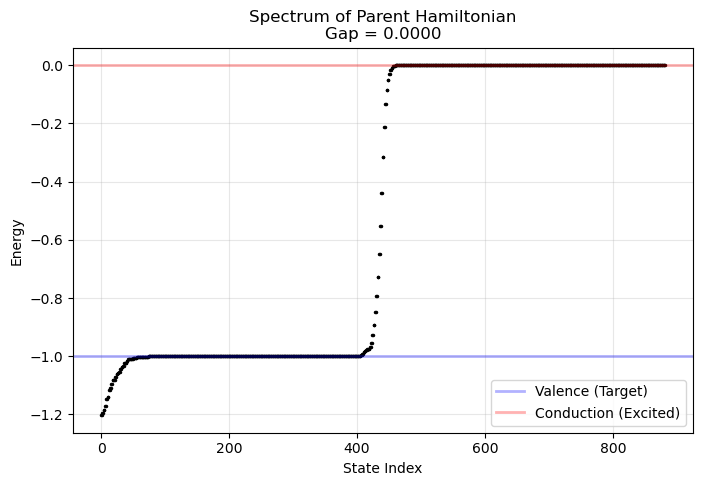


Number of in-gap (edge) modes: 14

 gap = 4.996003610813204e-16


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import fgtn.classA_U1FGTN as classA_U1FGTN
importlib.reload(classA_U1FGTN)
from fgtn.classA_U1FGTN import classA_U1FGTN
def analyze_parent_hamiltonian(sim, plot=True, exclude_dw=False):
    """
    Constructs H = - sum_R P_valence(R) from the class's OW projectors.
    Diagonalizes it to reveal the bulk bands and edge states.
    
    Parameters
    ----------
    sim : classA_U1FGTN
        The simulation instance containing WF_Am, WF_Bm, and geometry info.
    plot : bool
        Whether to plot the eigenspectrum.
    exclude_dw : bool
        If True, projectors centered at the domain wall coordinates (sim.DW_loc) 
        are excluded from the Hamiltonian sum. This creates an open boundary 
        condition for the bulk without 'stitching' the interface.
    """
    print("Constructing Parent Hamiltonian from OW projectors...")
    
    # 1. Flatten the Wannier spinors into matrices (Basis_Dim, N_centers)
    N_hilbert = 2 * sim.Nx * sim.Ny
    N_centers = sim.Nx * sim.Ny
    
    # Flatten using Fortran order to match the user's convention
    # Shape becomes (N_hilbert, N_sites)
    W_Am_flat = sim.WF_Am.reshape(N_hilbert, N_centers, order='F') 
    W_Bm_flat = sim.WF_Bm.reshape(N_hilbert, N_centers, order='F')
    
    # 2. Apply Exclusion Logic (if requested)
    if exclude_dw:
        if not (getattr(sim, "DW", False) and hasattr(sim, "DW_loc")):
            print("[Warn] exclude_dw=True but no DW locations found. Using full system.")
        else:
            print(f"Excluding projectors at DW locations: {sim.DW_loc}")
            
            # Create a 2D boolean mask for sites to keep
            # Shape (Nx, Ny) matches the spatial dimensions of WF arrays
            keep_mask = np.ones((sim.Nx, sim.Ny), dtype=bool)
            
            # Mask out the columns corresponding to DW x-coordinates
            for dw_x in sim.DW_loc:
                if 0 <= dw_x < sim.Nx:
                    keep_mask[dw_x, :] = False
            
            # Flatten the mask using the SAME order as the W matrices ('F')
            # This ensures the mask aligns with the column indices of W_flat
            keep_mask_flat = keep_mask.reshape(N_centers, order='F')
            
            # Apply filter
            W_Am_flat = W_Am_flat[:, keep_mask_flat]
            W_Bm_flat = W_Bm_flat[:, keep_mask_flat]
            
            print(f"Reduced projector count from {N_centers} to {W_Am_flat.shape[1]}")

    # 3. Build H = - sum (|w><w|)
    # P = W @ W^dag
    P_A = W_Am_flat @ W_Am_flat.conj().T
    P_B = W_Bm_flat @ W_Bm_flat.conj().T
    
    # Sum and scale
    H_parent = -1.0 * (P_A + P_B) / 2
    
    # 4. Diagonalize
    print("Diagonalizing...")
    evals, evecs = np.linalg.eigh(H_parent)
    
    # --- ADDED GAP ANALYSIS ---
    # Assuming half-filling (N_hilbert / 2)
    n_half = N_hilbert // 2
    homo = evals[n_half - 1]
    lumo = evals[n_half]
    gap = lumo - homo
    
    print("-" * 40)
    print(f"HOMO Energy: {homo:.6f}")
    print(f"LUMO Energy: {lumo:.6f}")
    print(f"Spectral Gap: {gap:.6f}")
    print("-" * 40)
    # ---------------------------
    
    # 5. Analyze Spectrum
    if plot:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(evals, '.', markersize=3, color='black')
        title_extra = " (DW Projectors Excluded)" if exclude_dw else ""
        ax.set_title(f"Spectrum of Parent Hamiltonian{title_extra}\nGap = {gap:.4f}")
        ax.set_ylabel("Energy")
        ax.set_xlabel("State Index")
        
        # Highlight regions
        ax.axhline(-1.0, color='blue', alpha=0.3, lw=2, label="Valence (Target)")
        ax.axhline(0.0, color='red', alpha=0.3, lw=2, label="Conduction (Excited)")
        
        # Draw Gap
        if gap > 1e-4:
            ax.annotate("", xy=(n_half, homo), xytext=(n_half, lumo),
                        arrowprops=dict(arrowstyle="<->", color="green", lw=1.5))
            ax.text(n_half + N_hilbert*0.05, (homo+lumo)/2, f"$\Delta={gap:.3f}$", 
                    color="green", va='center')
        
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.show()
        
    return evals, evecs, H_parent, gap

# --- Usage Example ---

# 1. Setup system
# Note: Ensure alpha_triv/alpha_top match your specific class version's init arguments
sim = classA_U1FGTN(Nx=21, Ny=21, DW=True, nshell=None, alpha_1=1000000, alpha_2=1)

# 2. Construct projectors
sim.construct_OW_projectors(nshell=None, DW=True)

# 3. Run analysis WITH exclusion
# This should show in-gap edge states created by the "open" boundary at the DW
evals, evecs, H, gap = analyze_parent_hamiltonian(sim, exclude_dw=False)

# 4. Check for edge states
in_gap = np.sum((evals > -0.8) & (evals < -0.2))
print(f"\nNumber of in-gap (edge) modes: {in_gap}")
print(f"\n gap = {gap}")

DWs at x=(5, 14)
------------------------- classA_U1FGTN Initialized -------------------------
Constructing Finite Region Hamiltonian (Carving)...
Defining finite region: x in [5, 14]
Summed 210 projectors out of 441 total sites.
Diagonalizing...
----------------------------------------
HOMO Energy: 0.000000
LUMO Energy: 0.000000
Spectral Gap: 0.000000
----------------------------------------


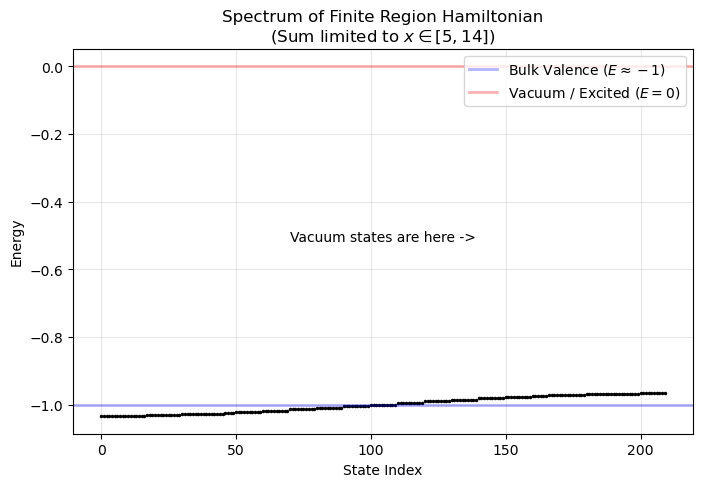

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_finite_region_hamiltonian(sim, plot=True):
    """
    Constructs H = - sum_{R in Region} P_valence(R).
    
    The region is defined as the space BETWEEN the domain walls.
    Sites outside this region are strictly ignored (H=0).
    """
    print("Constructing Finite Region Hamiltonian (Carving)...")
    
    Nx, Ny = sim.Nx, sim.Ny
    N_sites = Nx * Ny
    N_hilbert = 2 * N_sites
    
    # 1. Define the Finite Region
    if not (getattr(sim, "DW", False) and hasattr(sim, "DW_loc") and len(sim.DW_loc) >= 2):
        raise ValueError("Simulation must have DW=True and DW_loc defined.")
    
    dw_sorted = sorted(list(set(sim.DW_loc)))
    x_start = dw_sorted[0]
    x_end = dw_sorted[-1]
    
    # We define the region as INCLUSIVE of the walls (or you can tweak to be exclusive)
    # Let's assume inclusive [x_start, x_end] defines the "Island".
    print(f"Defining finite region: x in [{x_start}, {x_end}]")
    
    # 2. Prepare Projectors
    # We assume sim.WF_Am / WF_Bm are already computed (Topo or whatever bulk you want)
    W_Am_flat = sim.WF_Am.reshape(N_hilbert, N_sites, order='F') 
    
    # 3. Build Hamiltonian
    H_finite = np.zeros((N_hilbert, N_hilbert), dtype=np.complex128)
    
    # Only iterate over the columns inside the valid region
    projector_count = 0
    
    for x in range(x_start, x_end + 1):
        for y in range(Ny):
            site_idx = x * Ny + y
            
            # Get the Wannier function centered at this site
            chi = W_Am_flat[:, site_idx]
            
            # Add to Hamiltonian: H -= |chi><chi|
            H_finite -= np.outer(chi, chi.conj())
            projector_count += 1
            
    print(f"Summed {projector_count} projectors out of {N_sites} total sites.")

    # 4. Diagonalize
    print("Diagonalizing...")
    evals, evecs = np.linalg.eigh(H_finite)

    # --- ADDED GAP ANALYSIS ---
    # Assuming half-filling (N_hilbert / 2)
    n_half = N_hilbert // 2
    homo = evals[n_half - 1]
    lumo = evals[n_half]
    gap = lumo - homo
    
    print("-" * 40)
    print(f"HOMO Energy: {homo:.6f}")
    print(f"LUMO Energy: {lumo:.6f}")
    print(f"Spectral Gap: {gap:.6f}")
    print("-" * 40)
    # ---------------------------
    # 5. Plot
    if plot:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(evals[:210], '.', markersize=3, color='black')
        
        ax.set_title(f"Spectrum of Finite Region Hamiltonian\n(Sum limited to $x \in [{x_start}, {x_end}]$)")
        ax.set_ylabel("Energy")
        ax.set_xlabel("State Index")
        
        # Highlight regions
        ax.axhline(-1.0, color='blue', alpha=0.3, lw=2, label=r"Bulk Valence ($E \approx -1$)")
        ax.axhline(0.0, color='red', alpha=0.3, lw=2, label=r"Vacuum / Excited ($E = 0$)")
        
        # Annotation
        ax.text(0.5, 0.5, "Vacuum states are here ->", transform=ax.transAxes, ha='center')
        
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.show()
        
    return evals, evecs, H_finite

# --- Usage ---
sim = classA_U1FGTN(Nx=21, Ny=21, DW=True, nshell=2, alpha_1=30, alpha_2=1)

# Ensure projectors are built (using Bulk settings)
sim.alpha_profile = np.ones((sim.Nx, sim.Ny)) * 1.0 # Force uniform top for the "bulk" projectors
sim.construct_OW_projectors(nshell=2, DW=False)

# Analyze
evals, _, _ = analyze_finite_region_hamiltonian(sim)

DWs at x=(5, 14)
------------------------- classA_U1FGTN Initialized -------------------------
Constructing Overlapping Wannier Hamiltonian...
Generating Pure Topological Projectors (alpha=1.0)...
Generating Pure Trivial Projectors (alpha=30.0)...
Building H with overlap at DW locations: [5, 14]
Diagonalizing...


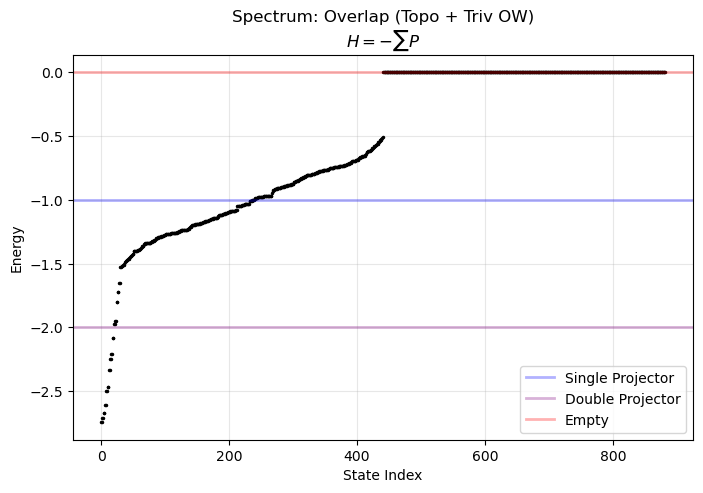

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_overlapping_wannier_hamiltonian(sim, alpha_top=1.0, alpha_triv=30.0, overlap_dw=True, plot=True):
    """
    Constructs a Parent Hamiltonian by mixing Topological and Trivial 
    Wannier Projectors.
    
    Parameters
    ----------
    alpha_top : float
        Mass parameter for the topological phase (Bulk).
    alpha_triv : float
        Mass parameter for the trivial phase (Vacuum).
    overlap_dw : bool
        If True, adds BOTH projectors at the boundary sites.
    """
    print("Constructing Overlapping Wannier Hamiltonian...")
    
    Nx, Ny = sim.Nx, sim.Ny
    N_sites = Nx * Ny
    N_hilbert = 2 * N_sites
    
    # 1. Store original state to restore later
    original_alpha = sim.alpha_profile.copy() if hasattr(sim, 'alpha_profile') else None
    
    # 2. Generate Set A: Pure Topological Projectors (Uniform alpha_top)
    print(f"Generating Pure Topological Projectors (alpha={alpha_top})...")
    sim.alpha_profile = np.ones((Nx, Ny)) * alpha_top
    sim.construct_OW_projectors(nshell=sim.nshell, DW=False)
    W_topo_flat = sim.WF_Am.reshape(N_hilbert, N_sites, order='F').copy()
    
    # 3. Generate Set B: Pure Trivial Projectors (Uniform alpha_triv)
    print(f"Generating Pure Trivial Projectors (alpha={alpha_triv})...")
    sim.alpha_profile = np.ones((Nx, Ny)) * alpha_triv
    sim.construct_OW_projectors(nshell=sim.nshell, DW=False)
    W_triv_flat = sim.WF_Am.reshape(N_hilbert, N_sites, order='F').copy()
    
    # Restore original state
    if original_alpha is not None:
        sim.alpha_profile = original_alpha

    # 4. Identify Regions
    if not (getattr(sim, "DW", False) and hasattr(sim, "DW_loc")):
        raise ValueError("Simulation must have DW=True and DW_loc defined.")
        
    dw_sorted = sorted(list(set(sim.DW_loc)))
    dw_set = set(sim.DW_loc)
    x_min, x_max = dw_sorted[0], dw_sorted[-1]
    
    # 5. Build Hamiltonian
    H_ov = np.zeros((N_hilbert, N_hilbert), dtype=np.complex128)
    
    print(f"Building H with overlap at DW locations: {list(dw_set)}")
    
    for x in range(Nx):
        for y in range(Ny):
            site_idx = x * Ny + y
            
            # Retrieve projectors for this specific site
            chi_topo = W_topo_flat[:, site_idx]
            chi_triv = W_triv_flat[:, site_idx]
            
            P_topo = np.outer(chi_topo, chi_topo.conj())
            P_triv = np.outer(chi_triv, chi_triv.conj())
            
            # --- Logic: Which Projector to add? ---
            
            # Case 1: Trivial Vacuum (Outside)
            if x < x_min or x > x_max:
                H_ov -= P_triv
                
            # Case 2: Topological Bulk (Inside)
            # strictly inside the walls
            elif x_min < x < x_max:
                H_ov -= P_topo
                
            # Case 3: The Domain Wall (The Boundary)
            elif x in dw_set:
                if overlap_dw:
                    # THE REQUEST: Add BOTH projectors
                    H_ov -= P_topo
                    H_ov -= P_triv
                else:
                    # Default to Topo if no overlap requested
                    H_ov -= P_topo 

    # 6. Diagonalize
    print("Diagonalizing...")
    evals, evecs = np.linalg.eigh(H_ov)

    # --- ADDED GAP ANALYSIS ---
    # Assuming half-filling (N_hilbert / 2)
    n_half = N_hilbert // 2
    homo = evals[n_half - 1]
    lumo = evals[n_half]
    gap = lumo - homo
    
    print("-" * 40)
    print(f"HOMO Energy: {homo:.6f}")
    print(f"LUMO Energy: {lumo:.6f}")
    print(f"Spectral Gap: {gap:.6f}")
    print("-" * 40)
    # ---------------------------
    
    # 7. Plot
    if plot:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(evals, '.', markersize=3, color='black')
        
        mode = "Overlap (Topo + Triv OW)" if overlap_dw else "Standard Stitched"
        ax.set_title(f"Spectrum: {mode}\n$H = - \sum P$")
        ax.set_ylabel("Energy")
        ax.set_xlabel("State Index")
        
        # Highlight regions
        ax.axhline(-1.0, color='blue', alpha=0.3, lw=2, label="Single Projector")
        ax.axhline(-2.0, color='purple', alpha=0.3, lw=2, label="Double Projector")
        ax.axhline(0.0, color='red', alpha=0.3, lw=2, label="Empty")
        
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.show()
        
    return evals, evecs, H_ov

# --- Usage ---
sim = classA_U1FGTN(Nx=21, Ny=21, DW=True, nshell=2) # Init args don't matter much here since we overwrite alpha_profile

# Pass the alphas explicitly here
evals, _, _ = analyze_overlapping_wannier_hamiltonian(sim, alpha_top=1.0, alpha_triv=30.0, overlap_dw=True)

DWs at x=(3, 8)
------------------------- classA_U1FGTN Initialized -------------------------
Constructing Hybrid Hamiltonian...
Building H on 12x12 lattice. Bulk region: x in [3, 8]
Diagonalizing Hybrid H...
----------------------------------------
HOMO Energy: -0.129915
LUMO Energy: -0.000000
Spectral Gap: 0.129915
----------------------------------------


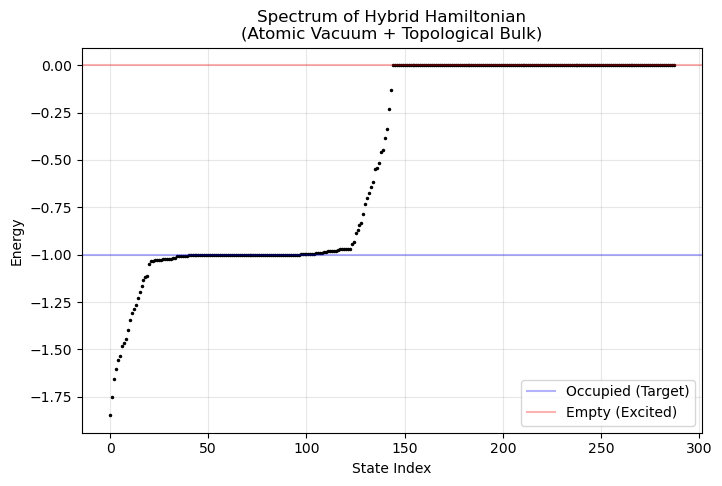

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_hybrid_hamiltonian(sim, plot=True, exclude_dw=False, s=0):
    """
    Constructs a hybrid parent Hamiltonian:
    - Bulk Region (between DWs): H = - sum P_OW (Topological Overcomplete Wannier)
    - Trivial Region (outside):  H = - sum P_atomic (Atomic limit, spin-down)
    
    Parameters
    ----------
    sim : classA_U1FGTN
        Simulation object.
    plot : bool
        If True, plots the spectrum.
    exclude_dw : bool
        If True, no projectors are added at the domain wall sites (x in DW_loc).
        This effectively disconnects the bulk from the vacuum at the interface,
        leaving the DW sites with 0 energy (part of the conduction manifold).
    """
    print("Constructing Hybrid Hamiltonian...")
    
    # 1. Setup Grid and Dimensions
    Nx, Ny = sim.Nx, sim.Ny
    N_sites = Nx * Ny
    N_hilbert = 2 * N_sites
    
    # Identify Regions
    if not (getattr(sim, "DW", False) and hasattr(sim, "DW_loc") and len(sim.DW_loc) >= 2):
        raise ValueError("Simulation must have DW=True and DW_loc defined.")
        
    dw_sorted = sorted(list(set(sim.DW_loc)))
    x0 = sim.DW_loc[0]
    x1 = sim.DW_loc[1]
    dw_set = np.unique(np.concatenate((np.arange(x0-s, x0), np.arange(x1,x1+s))))
    x_min, x_max = dw_sorted[0], dw_sorted[-1]
    
    # 2. Pre-compute Bulk Projectors (OW)
    # Flatten source arrays for easy indexing: (N_hilbert, N_sites)
    W_Am_flat = sim.WF_Am.reshape(N_hilbert, N_sites, order='F') 
    
    # 3. Construct Hamiltonian Term by Term
    H_hybrid = np.zeros((N_hilbert, N_hilbert), dtype=np.complex128)
    
    print(f"Building H on {Nx}x{Ny} lattice. Bulk region: x in [{x_min}, {x_max}]")
    if exclude_dw:
        print(f"Excluding projectors at DW locations: {list(dw_set)}")
    
    for x in range(Nx):
        # --- Exclusion Logic ---
        if exclude_dw and (x in dw_set):
            # Skip this x-slice entirely (effectively Open Boundary Conditions)
            continue

        for y in range(Ny):
            site_idx = x * Ny + y 
            
            # --- Trivial Region (Eraser) ---
            if x < x_min or x > x_max:
                # Projector onto "mu=2" (Atomic limit spin-down)
                # Basis index: 2*site_idx + 1
                idx_down = 2 * site_idx + 1
                
                # H -= |down><down|
                H_hybrid[idx_down, idx_down] -= 1.0
                
            # --- Topological Bulk (Carving) ---
            else:
                # Projector onto OW lower band
                chi = W_Am_flat[:, site_idx]
                
                # H -= |chi><chi|
                H_hybrid -= np.outer(chi, chi.conj())

    # 4. Diagonalize
    print("Diagonalizing Hybrid H...")
    evals, evecs = np.linalg.eigh(H_hybrid)
    
    # --- ADDED GAP ANALYSIS ---
    # Assuming half-filling (N_hilbert / 2)
    n_half = N_hilbert // 2
    homo = evals[n_half - 1]
    lumo = evals[n_half]
    gap = lumo - homo
    
    print("-" * 40)
    print(f"HOMO Energy: {homo:.6f}")
    print(f"LUMO Energy: {lumo:.6f}")
    print(f"Spectral Gap: {gap:.6f}")
    print("-" * 40)
    
    # ---------------------------
    # 5. Plotting
    if plot:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(evals, '.', markersize=3, color='black')
        title_extra = " (DW Excluded)" if exclude_dw else ""
        ax.set_title(f"Spectrum of Hybrid Hamiltonian{title_extra}\n(Atomic Vacuum + Topological Bulk)")
        ax.set_ylabel("Energy")
        ax.set_xlabel("State Index")
        
        # Reference lines
        ax.axhline(-1.0, color='blue', alpha=0.3, label="Occupied (Target)")
        ax.axhline(0.0, color='red', alpha=0.3, label="Empty (Excited)")
        
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.show()
        
    return evals, evecs, H_hybrid

# --- Usage ---
sim = classA_U1FGTN(Nx=12, Ny=12, DW=True, alpha_1=30, alpha_2=1) # Uniform mass param
sim.construct_OW_projectors(nshell=None, DW=True) # Build uniform alpha=1 projectors

# Run with exclusion
evals, _, _ = analyze_hybrid_hamiltonian(sim, exclude_dw=False)

Starting Gap Scaling Analysis for sizes: [8, 10, 20, 30]
Parameters: alpha_triv=30, alpha_top=1, exclude_dw=False
------------------------------------------------------------
Size (Nx=Ny)    | Gap          | HOMO         | LUMO        
------------------------------------------------------------
DWs at x=(2, 5)
------------------------- classA_U1FGTN Initialized -------------------------
Constructing Hybrid Hamiltonian...
Building H on 8x8 lattice. Bulk region: x in [2, 5]
Diagonalizing Hybrid H...
----------------------------------------
HOMO Energy: -0.228429
LUMO Energy: -0.000000
Spectral Gap: 0.228429
----------------------------------------
8               | 0.228429       | -0.228429       | -0.000000
DWs at x=(2, 7)
------------------------- classA_U1FGTN Initialized -------------------------
Constructing Hybrid Hamiltonian...
Building H on 10x10 lattice. Bulk region: x in [2, 7]
Diagonalizing Hybrid H...
----------------------------------------
HOMO Energy: -0.129313
LUMO Ener

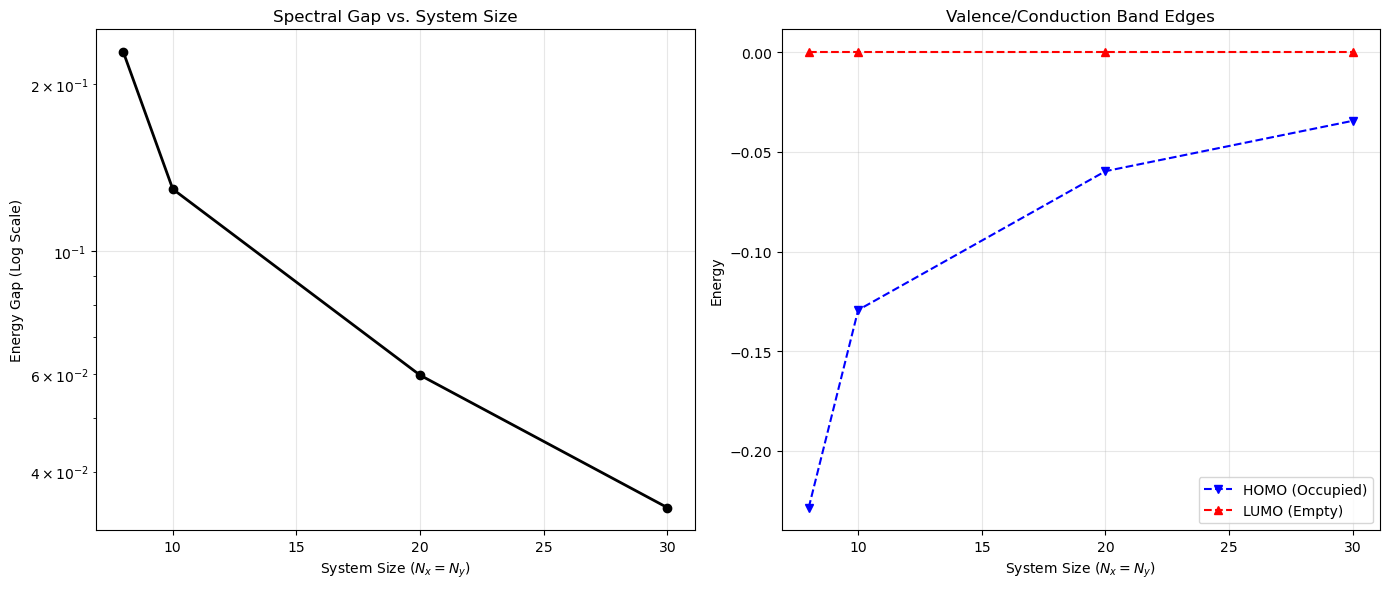

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import fgtn.classA_U1FGTN as classA_U1FGTN
# importlib.reload(classA_U1FGTN) # Uncomment if actively editing the class
from fgtn.classA_U1FGTN import classA_U1FGTN
# --- 1. Re-define your Analyzer to run quietly ---
def get_gap_for_size(Nx, Ny, alpha_triv=30, alpha_top=1, exclude_dw=False, s=0):
    """
    Instantiates the simulation for a specific size and calculates the spectral gap.
    Returns: (gap, homo, lumo)
    """
    # Initialize Simulation
    # Note: Adjust args (alpha_1 vs alpha_triv) to match your exact class definition
    sim = classA_U1FGTN(Nx=Nx, Ny=Ny, DW=True, alpha_1=alpha_triv, alpha_2=alpha_top)
    
    # Construct Projectors
    # nshell=None usually implies using default/max shell logic in your class
    sim.construct_OW_projectors(nshell=None, DW=True)
    
    # Run the Hamiltonian Construction (reusing your existing logic)
    # We turn plot=False to speed up the loop
    evals, _, _ = analyze_hybrid_hamiltonian(sim, plot=False, exclude_dw=exclude_dw, s=s)
    
    # Extract Gap
    N_hilbert = len(evals)
    n_half = N_hilbert // 2
    
    homo = evals[n_half - 1]
    lumo = evals[n_half]
    gap = lumo - homo
    
    return gap, homo, lumo

# --- 2. The Analysis Loop ---

def analyze_gap_scaling(sizes, alpha_triv=30, alpha_top=1, exclude_dw=False):
    gaps = []
    homos = []
    lumos = []
    
    print(f"Starting Gap Scaling Analysis for sizes: {sizes}")
    print(f"Parameters: alpha_triv={alpha_triv}, alpha_top={alpha_top}, exclude_dw={exclude_dw}")
    print("-" * 60)
    print(f"{'Size (Nx=Ny)':<15} | {'Gap':<12} | {'HOMO':<12} | {'LUMO':<12}")
    print("-" * 60)
    
    for L in sizes:
        try:
            # We assume a square lattice Nx = Ny = L for simplicity
            gap, h, l = get_gap_for_size(L, L, alpha_triv, alpha_top, exclude_dw)
            
            gaps.append(gap)
            homos.append(h)
            lumos.append(l)
            
            print(f"{L:<15} | {gap:.6f}       | {h:.6f}       | {l:.6f}")
            
        except Exception as e:
            print(f"Skipping size {L} due to error: {e}")
            gaps.append(np.nan)

    # --- 3. Visualization ---
    gaps = np.array(gaps)
    valid_sizes = np.array(sizes)[~np.isnan(gaps)]
    valid_gaps = gaps[~np.isnan(gaps)]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Gap Magnitude
    ax1.plot(valid_sizes, valid_gaps, 'o-', color='black', lw=2, label='Spectral Gap')
    ax1.set_xlabel('System Size ($N_x=N_y$)')
    ax1.set_ylabel('Energy Gap $\Delta E$')
    ax1.set_title('Spectral Gap vs. System Size')
    ax1.grid(True, alpha=0.3)
    
    # Check for exponential closing (Log Scale) if gap is small
    if np.min(valid_gaps) < 0.1:
        ax1.set_yscale('log')
        ax1.set_ylabel('Energy Gap (Log Scale)')
        
    # Plot 2: HOMO/LUMO Levels
    ax2.plot(valid_sizes, homos, 'v--', color='blue', label='HOMO (Occupied)')
    ax2.plot(valid_sizes, lumos, '^--', color='red', label='LUMO (Empty)')
    ax2.set_xlabel('System Size ($N_x=N_y$)')
    ax2.set_ylabel('Energy')
    ax2.set_title('Valence/Conduction Band Edges')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# --- Run It ---
# Define a range of sizes. 
# Keep max size reasonable (e.g., 20) as diagonalization is O(N^3) = O(L^6)
system_sizes = [8, 10, 20, 30] 

# Case A: Standard Hybrid (Stitched) -> Expect non-zero gap for topological bulk?
analyze_gap_scaling(system_sizes, alpha_triv=30, alpha_top=1, exclude_dw=False)

Starting Gap Scaling Analysis for sizes: [8, 12, 16, 20]
Params: a_triv=30, a_top=1, exclude=False
-----------------------------------------------------------------
Size       | Gap          | HOMO         | LUMO        
-----------------------------------------------------------------
DWs at x=(2, 5)
------------------------- classA_U1FGTN Initialized -------------------------
Constructing Hybrid Hamiltonian...
Building H on 8x8 lattice. Bulk region: x in [2, 5]
Diagonalizing Hybrid H...
----------------------------------------
HOMO Energy: -0.228429
LUMO Energy: -0.000000
Spectral Gap: 0.228429
----------------------------------------
8          | 0.228429       | -0.228429       | -0.000000
DWs at x=(3, 8)
------------------------- classA_U1FGTN Initialized -------------------------
Constructing Hybrid Hamiltonian...
Building H on 12x12 lattice. Bulk region: x in [3, 8]
Diagonalizing Hybrid H...
----------------------------------------
HOMO Energy: -0.129915
LUMO Energy: -0.000000
S

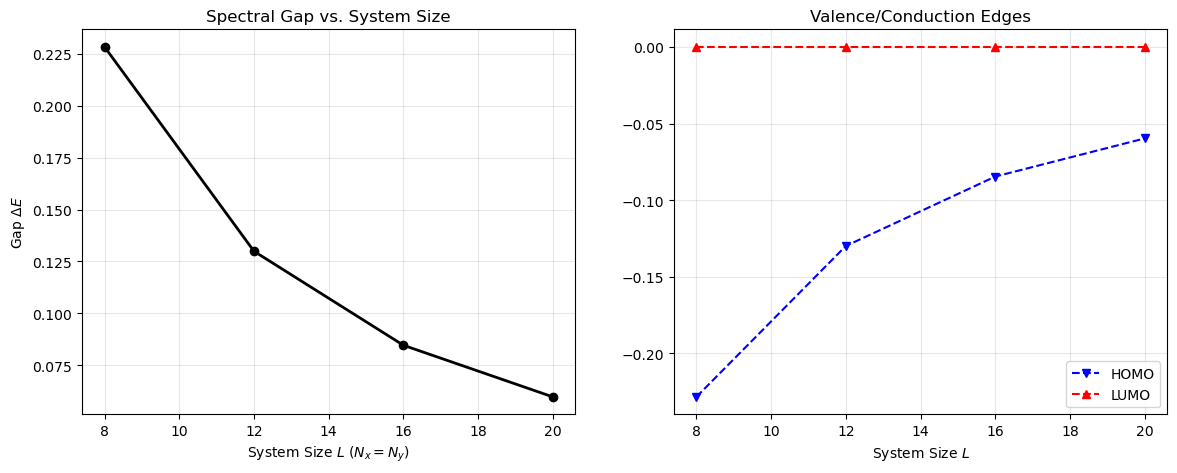

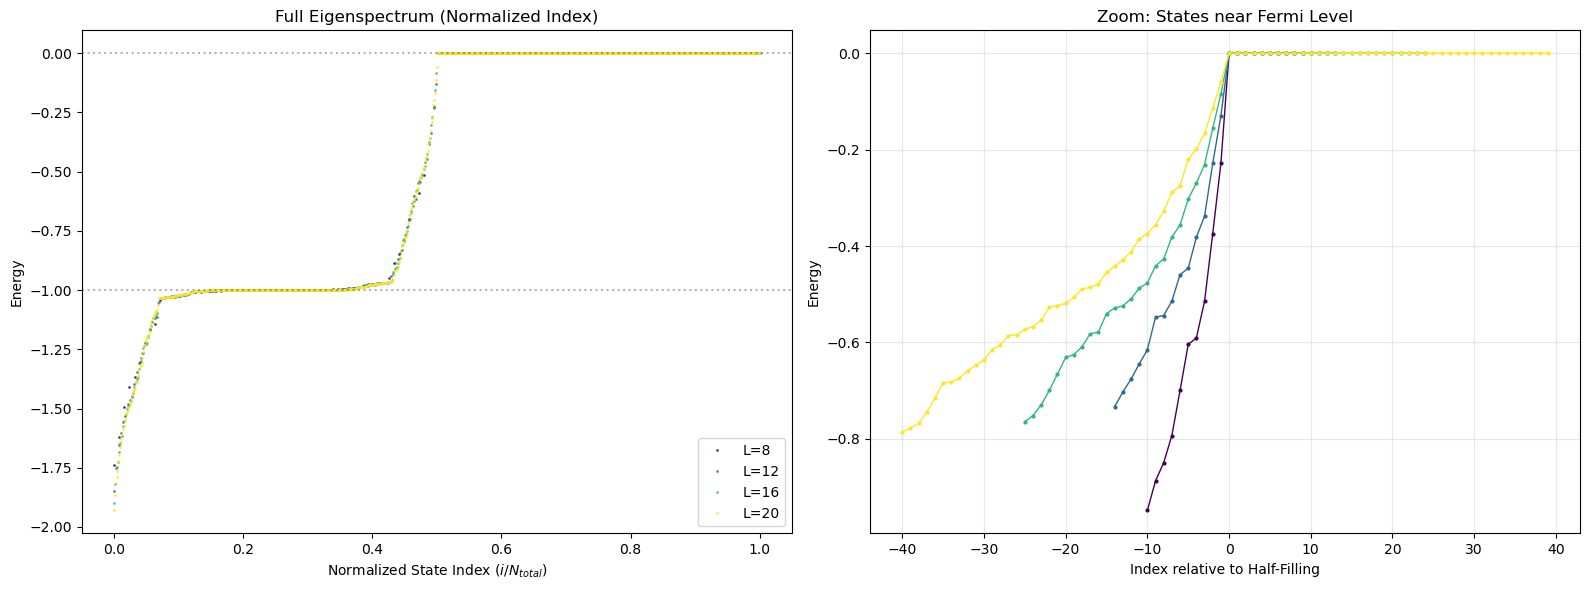

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import importlib
import fgtn.classA_U1FGTN as classA_U1FGTN
# importlib.reload(classA_U1FGTN) 
from fgtn.classA_U1FGTN import classA_U1FGTN
# --- 1. Helper to run one size ---
def get_spectrum_for_size(Nx, Ny, alpha_triv=30, alpha_top=1, exclude_dw=False, s=0):
    """
    Runs simulation for LxL and returns the full spectrum and gap metrics.
    """
    # Initialize
    sim = classA_U1FGTN(Nx=Nx, Ny=Ny, DW=True, alpha_1=alpha_triv, alpha_2=alpha_top)
    
    # Construct Projectors
    sim.construct_OW_projectors(nshell=None, DW=True)
    
    # Run Hamiltonian (reuse existing function, plot=False)
    # Ensure 'analyze_hybrid_hamiltonian' is defined in your scope
    evals, _, _ = analyze_hybrid_hamiltonian(sim, plot=False, exclude_dw=exclude_dw, s=s)
    
    # Calculate Metrics
    N_hilbert = len(evals)
    n_half = N_hilbert // 2
    
    homo = evals[n_half - 1]
    lumo = evals[n_half]
    gap = lumo - homo
    
    return gap, homo, lumo, evals

# --- 2. Main Analysis Function ---
def analyze_gap_scaling(sizes, alpha_triv=30, alpha_top=1, exclude_dw=False, s=0):
    gaps = []
    homos = []
    lumos = []
    all_evals = [] # Store full arrays
    
    print(f"Starting Gap Scaling Analysis for sizes: {sizes}")
    print(f"Params: a_triv={alpha_triv}, a_top={alpha_top}, exclude={exclude_dw}")
    print("-" * 65)
    print(f"{'Size':<10} | {'Gap':<12} | {'HOMO':<12} | {'LUMO':<12}")
    print("-" * 65)
    
    for L in sizes:
        try:
            gap, h, l, evals = get_spectrum_for_size(L, L, alpha_triv, alpha_top, exclude_dw, s)
            
            gaps.append(gap)
            homos.append(h)
            lumos.append(l)
            all_evals.append(evals)
            
            print(f"{L:<10} | {gap:.6f}       | {h:.6f}       | {l:.6f}")
            
        except Exception as e:
            print(f"Skipping L={L}: {e}")
            gaps.append(np.nan)
            all_evals.append(None)

    # --- 3. Visualization ---
    gaps = np.array(gaps)
    valid_mask = ~np.isnan(gaps)
    valid_sizes = np.array(sizes)[valid_mask]
    
    # FIGURE 1: Scaling Laws
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Gap Magnitude
    ax1.plot(valid_sizes, gaps[valid_mask], 'o-', color='k', lw=2)
    ax1.set_title('Spectral Gap vs. System Size')
    ax1.set_xlabel('System Size $L$ ($N_x=N_y$)')
    ax1.set_ylabel('Gap $\Delta E$')
    ax1.grid(True, alpha=0.3)
    if np.min(gaps[valid_mask]) < 0.01: ax1.set_yscale('log') # Log scale if gap vanishes
        
    # Right: Band Edges
    ax2.plot(valid_sizes, np.array(homos)[valid_mask], 'v--', label='HOMO', color='blue')
    ax2.plot(valid_sizes, np.array(lumos)[valid_mask], '^--', label='LUMO', color='red')
    ax2.set_title('Valence/Conduction Edges')
    ax2.set_xlabel('System Size $L$')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.show()
    
    # FIGURE 2: Spectra Evolution
    # We create a color map to distinguish sizes
    colors = cm.viridis(np.linspace(0, 1, len(valid_sizes)))
    
    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6))
    
    for i, size in enumerate(valid_sizes):
        e = all_evals[i]
        if e is None: continue
        
        # Normalize index to [0, 1] to compare shapes independent of N
        norm_idx = np.linspace(0, 1, len(e))
        
        ax3.plot(norm_idx, e, '.', markersize=2, label=f'L={size}', color=colors[i], alpha=0.7)
        
        # Zoomed Plot (Center 10% of states)
        center = len(e) // 2
        window = max(10, int(0.05 * len(e))) # Show +/- 5% around Fermi level
        zoom_indices = np.arange(center - window, center + window)
        ax4.plot(zoom_indices - center, e[zoom_indices], '.-', markersize=4, label=f'L={size}', color=colors[i], lw=1)

    # Plot 1: Full Range
    ax3.set_title('Full Eigenspectrum (Normalized Index)')
    ax3.set_xlabel('Normalized State Index ($i / N_{total}$)')
    ax3.set_ylabel('Energy')
    ax3.axhline(-1.0, c='k', ls=':', alpha=0.3)
    ax3.axhline(0.0, c='k', ls=':', alpha=0.3)
    ax3.legend()
    
    # Plot 2: Zoomed Gap
    ax4.set_title('Zoom: States near Fermi Level')
    ax4.set_xlabel('Index relative to Half-Filling')
    ax4.set_ylabel('Energy')
    ax4.grid(True, alpha=0.3)
    # ax4.set_ylim(-0.2, 0.2) # Optional: Hard zoom if gap is small
    
    plt.tight_layout()
    plt.show()

# --- Run It ---
# Suggestion: Use even numbers for clean half-filling
system_sizes = [8, 12, 16, 20] 

# Run Analysis
analyze_gap_scaling(system_sizes, alpha_triv=30, alpha_top=1, exclude_dw=False)

In [1]:
import numpy as np
import time

n = 2500
rng = np.random.default_rng(0)

# Random dense complex matrix
A = rng.standard_normal((n, n)) + 1j * rng.standard_normal((n, n))

t0 = time.perf_counter()
w, v = np.linalg.eig(A)
t1 = time.perf_counter()

print(f"eig() time: {t1 - t0:.3f} s")
print(f"eigenvalues shape: {w.shape}, eigenvectors shape: {v.shape}")


eig() time: 14.720 s
eigenvalues shape: (2500,), eigenvectors shape: (2500, 2500)
